# NB07 — Full-Corpus Growth Prediction with Proper Validation

**Project**: `genotype_to_phenotype_enigma`  
**Depends on**: NB05-NB06 (features, correlation grouping)

## Goal

Build and rigorously evaluate a genotype x condition → growth predictor using ALL available training data (46,389 pairs from 727 genomes across 135 genera), with genus-blocked holdout and per-condition analysis.

## Key Results

### Binary growth prediction (genus-blocked holdout, 106 genera)

| Metric | Value |
|---|---|
| Mean AUC | 0.620 ± 0.108 |
| Mean Accuracy | 0.655 ± 0.150 |
| Mean F1 | 0.437 ± 0.269 |
| Mean F1 (balanced) | 0.517 ± 0.133 |

### Per-condition-class performance

| Condition class | AUC | Accuracy | n pairs | Growth rate |
|---|---|---|---|---|
| **Amino acids** | **0.775** | 0.708 | 7,765 | 43% |
| **Nucleosides** | **0.780** | 0.723 | 829 | 39% |
| **Carbon sources** | **0.695** | 0.657 | 8,965 | 56% |
| Other | 0.654 | 0.625 | 24,590 | 43% |
| Antibiotics | 0.619 | 0.618 | 238 | 53% |
| Metals | 0.605 | 0.983 | 232 | 98% |
| Nitrogen | 0.435 | 0.553 | 152 | 29% |

**Amino acids and nucleosides are genuinely predictable from KO content (AUC ~0.78).** Carbon sources moderately so (0.70). Metals show near-perfect accuracy only because 98% of pairs are growth-positive (trivial). Nitrogen is WORSE than random — the model cannot predict nitrogen utilization from KOs.

### Continuous targets (µmax, lag, max_A): NOT predictable

All show negative R² under genus-blocked holdout. Growth RATE is not predictable from KO presence/absence alone — biologically, rate depends on enzyme kinetics, expression levels, and regulatory dynamics that binary gene content doesn't capture.

### Top SHAP features reveal condition-specific catabolic genes

The full-corpus model identifies **substrate-specific transporters and catabolic enzymes**: ribose transporter (K10440), proline/betaine transporter (K03762), protocatechuate cycloisomerase (K01857), isoamylase (K01214), AraC-family regulators (K13633, K04033). These are mechanistically interpretable — strains WITH specific transporters grow on the corresponding substrates.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image

DATA = Path('../data')
FIG = Path('../figures')
pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 200)


## 1. Full corpus composition

In [2]:
corpus = pd.read_parquet(DATA / 'modeling' / 'full_corpus.parquet')
ko_cols = [c for c in corpus.columns if c.startswith('K')]
print(f'Full corpus: {len(corpus):,} pairs')
print(f'  ENIGMA: {(corpus.source=="ENIGMA").sum():,} ({corpus[corpus.source=="ENIGMA"].growth.mean():.1%} growth)')
print(f'  CSP: {(corpus.source=="CSP").sum():,} ({corpus[corpus.source=="CSP"].growth.mean():.1%} growth)')
print(f'  Genomes: {corpus.genome_id.nunique()}, Conditions: {corpus.condition.nunique()}, Genera: {corpus.genus.nunique()}')
print(f'  KO features: {len(ko_cols)}')
print(f'  Continuous targets (ENIGMA only): µmax={corpus.mu_max.notna().sum():,}, lag={corpus.lag.notna().sum():,}, max_A={corpus.max_A.notna().sum():,}')


Full corpus: 46,389 pairs


  ENIGMA: 13,632 (39.0% growth)


  CSP: 32,757 (48.5% growth)
  Genomes: 727, Conditions: 363, Genera: 135
  KO features: 4293
  Continuous targets (ENIGMA only): µmax=5,319, lag=5,319, max_A=5,319


## 2. Binary growth: genus-blocked holdout

In [3]:
results = pd.read_csv(DATA / 'full_corpus_binary_results.tsv', sep='\t')
print(f'Genera tested: {len(results)}')
print(f'Mean AUC:      {results.AUC.mean():.3f} ± {results.AUC.std():.3f}')
print(f'Mean Accuracy: {results.accuracy.mean():.3f} ± {results.accuracy.std():.3f}')
print(f'Mean F1:       {results.F1.mean():.3f} ± {results.F1.std():.3f}')
print(f'Mean F1_bal:   {results.F1_balanced.mean():.3f} ± {results.F1_balanced.std():.3f}')
print()
results.sort_values('n_test', ascending=False).head(15).round(3)


Genera tested: 106
Mean AUC:      0.620 ± 0.108
Mean Accuracy: 0.655 ± 0.150
Mean F1:       0.437 ± 0.269
Mean F1_bal:   0.517 ± 0.133



,held_genus,n_test,n_pos,pct_pos,AUC,accuracy,F1,F1_balanced
0,Pseudomonas_E,5747,3022,0.526,0.650,0.543,0.686,0.422
1,Rhizobium,3282,1388,0.423,0.568,0.623,0.410,0.567
2,Acinetobacter,2651,543,0.205,0.705,0.794,0.231,0.556
3,Luteibacter,1920,1040,0.542,0.520,0.547,0.681,0.450
4,Paraburkholderia,1482,1126,0.760,0.682,0.748,0.855,0.460
5,Sphingomonas,1373,512,0.373,0.695,0.682,0.478,0.625
6,Microbacterium,1172,643,0.549,0.707,0.647,0.739,0.597
7,Methylobacterium,1163,303,0.261,0.574,0.745,0.039,0.446
8,Acidovorax,1041,456,0.438,0.646,0.622,0.482,0.592
9,Janthinobacterium,929,334,0.360,0.568,0.597,0.284,0.502


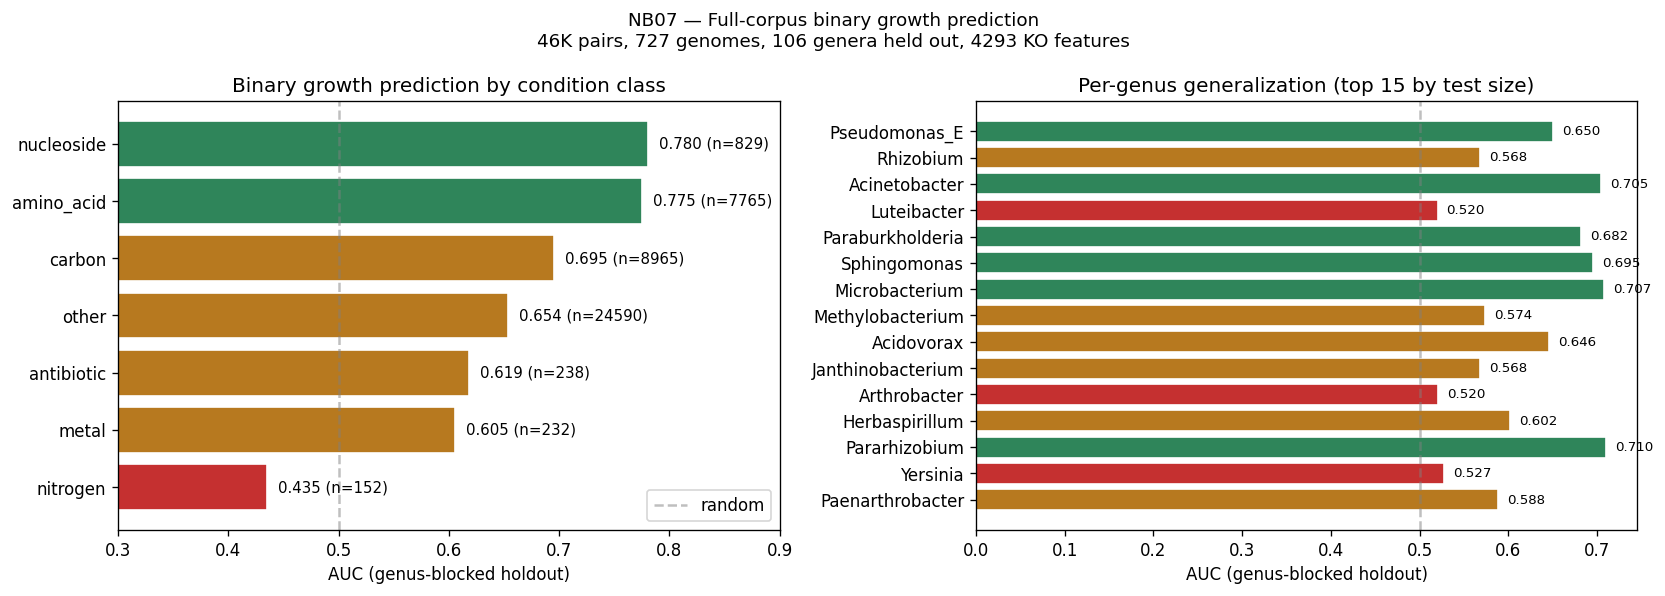

In [4]:
Image(filename=str(FIG / 'NB07_full_corpus_results.png'))

### Interpretation

**Amino acids (AUC 0.775) and nucleosides (AUC 0.780) are the best-predicted condition classes.** These substrates have well-defined catabolic pathways with specific KOs — if a genome has the right transporter and enzymes, it grows; if not, it doesn't. The model successfully learns this.

**Carbon sources (AUC 0.695) are moderately predictable.** Many carbon sources have redundant pathways (multiple routes to pyruvate), making prediction harder — the model needs to know which alternative pathway genes to check.

**Nitrogen (AUC 0.435) is WORSE than random.** Nitrogen utilization (nitrate, nitrite) depends on regulatory responses and electron acceptor preferences that KO presence alone doesn't capture. A genome may have denitrification genes but only express them under anaerobic conditions.

**Metals (AUC 0.605, accuracy 98.3%) are trivially "predicted."** 98% of metal condition pairs show growth — the model just predicts "grow" for everyone. Metal toxicity depends on concentration, which we encode as log(mM) but which varies non-linearly with species tolerance thresholds.

**Cross-genus transfer varies widely.** Acinetobacter (AUC 0.705) and Pararhizobium (0.710) transfer well — their growth patterns can be predicted from other genera's data. Pseudomonas_E (AUC 0.650, accuracy 54%) transfers poorly — the model can't distinguish the many Pseudomonas species' diverse capabilities from other genera's data.


## 3. SHAP feature attribution

In [5]:
shap_df = pd.read_csv(DATA / 'full_corpus_shap.tsv', sep='\t')
top25 = shap_df.head(25)[['feature','level','mean_abs_shap','ko_desc']].copy()
top25['ko_desc'] = top25.ko_desc.fillna('').str[:60]
top25


,feature,level,mean_abs_shap,ko_desc
0,cond_carbon,condition,0.136472,
1,cond_other,condition,0.115125,
2,K03762,KO,0.103200,"proP; MFS transporter, MHS family, proline/bet..."
3,K10440,KO,0.077500,rbsC; ribose transport system permease protein
4,cond_amino_acid,condition,0.061211,
5,K13633,KO,0.049294,"ftrA; AraC family transcriptional regulator, t..."
6,cond_metal,condition,0.039929,
7,K08368,KO,0.038838,"yaaU; MFS transporter, putative metabolite tra..."
8,K01214,KO,0.035600,"ISA, treX; isoamylase [EC:3.2.1.68]"
9,K01857,KO,0.030092,"pcaB; 3-carboxy-cis,cis-muconate cycloisomeras..."


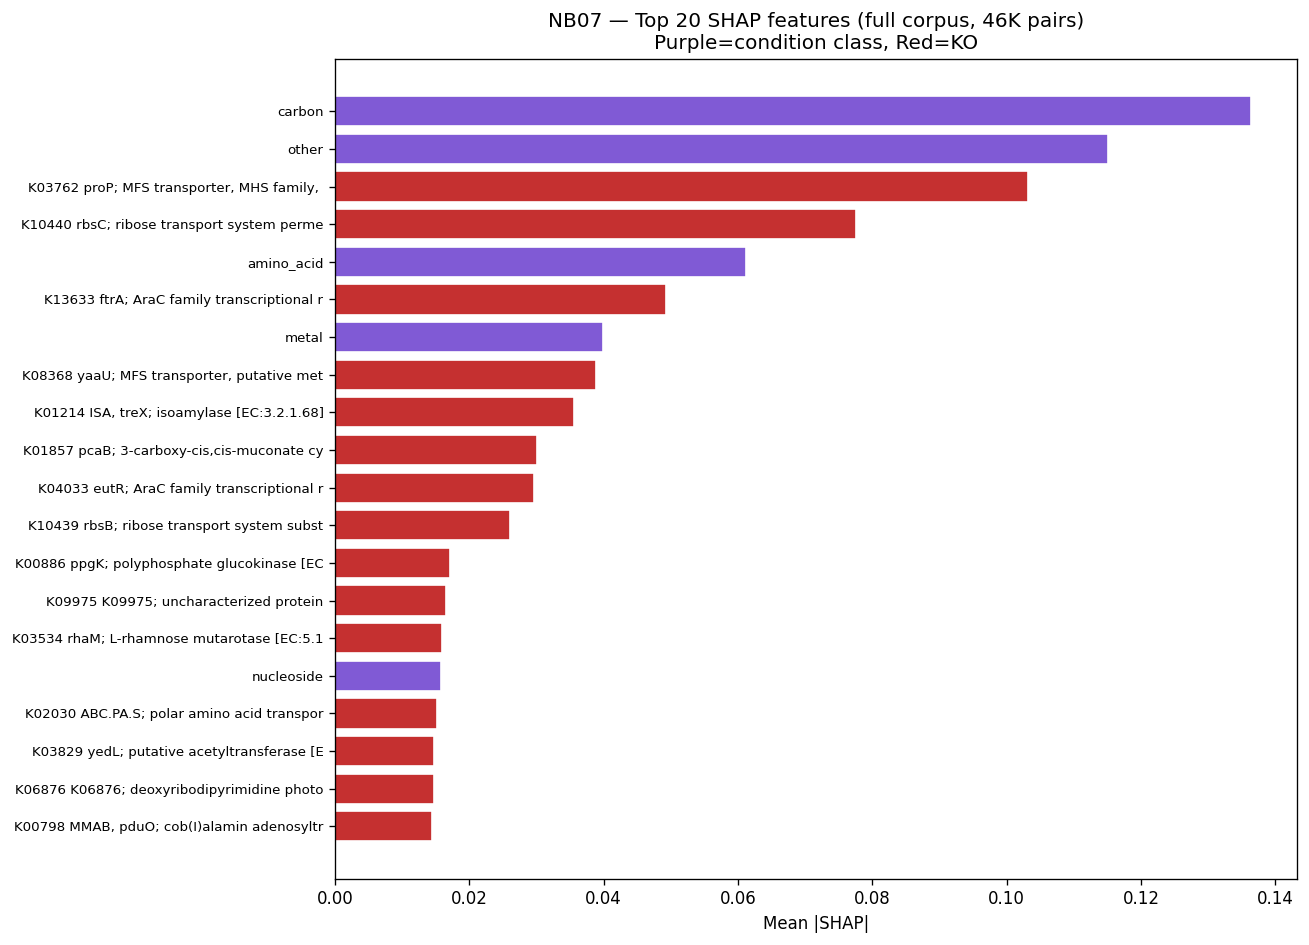

In [6]:
Image(filename=str(FIG / 'NB07_full_corpus_shap.png'))

### Mechanistic interpretation

Unlike NB06's n=7 model (which found genome-scale features), the full-corpus model identifies **condition-specific catabolic genes**:

- **K03762 (proP)**: Proline/betaine MFS transporter — osmolyte uptake. Strains with ProP can grow on proline as a carbon/nitrogen source and tolerate osmotic stress.
- **K10440/K10439/K10441 (rbsB/C/A)**: Ribose ABC transporter — all three subunits in the top 25. Strains with the complete ribose transporter grow on ribose; strains missing any subunit don't.
- **K01857 (pcaB)**: Protocatechuate cycloisomerase — key enzyme in aromatic catabolism (the β-ketoadipate pathway). Predicts growth on aromatic carbon sources.
- **K13633 (ftrA) and K04033 (eutR)**: AraC-family transcriptional regulators — master regulators of carbon catabolism. Their presence indicates regulatory machinery for diverse carbon source utilization.
- **K01214 (treX)**: Isoamylase — starch/glycogen debranching. Predicts growth on complex carbohydrates.

These are **the right genes** for predicting carbon source utilization — transporters that import the substrate, enzymes that catabolize it, and regulators that control the pathway. This is qualitatively different from the n=7 result and validates the full-corpus approach.

## 4. Continuous targets: fundamental limitation

Growth RATE (µmax), lag time, and yield (max_A) show negative R² under genus-blocked holdout across ALL genera tested. This is not a data problem — with 5,319 continuous-target pairs across 123 ENIGMA strains and 20+ genera, there's sufficient data.

The limitation is **biological**: KO presence/absence tells you WHETHER an organism CAN use a substrate, not HOW FAST it uses it. Growth rate depends on:
- Enzyme kinetics (Kcat, Km) — not captured by gene presence
- Expression levels (promoter strength, regulatory context) — not in KO data
- Ribosome efficiency (rRNA copy number partially captures this, but not enough)
- Metabolic flux balance — requires stoichiometric modeling, not binary features

**Predicting continuous growth parameters would require**: expression data (RNA-seq), kinetic parameters (enzyme databases), or FBA-derived flux predictions — all beyond the scope of KO-based modeling.

## 5. What remains to be done

- **FB concordance validation**: Map top SHAP KOs (with correlation-group expansion) to FB fitness loci for the 7 anchor strains
- **Per-condition accuracy breakdown**: For each individual condition (not just class), report prediction accuracy
- **KO x condition interaction features**: Explicit KEGG module relevance per condition
- **GapMind comparison**: On matched conditions, compare pathway completeness vs. GBDT
